In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
d = pd.read_csv('social_media_engagement_dataset.csv')
d

,platform,post_type,post_length,views,likes,comments,shares,engagement_rate
0,Facebook,Text,62,91660,2968,276,346,0.039166
1,Instagram,Video,104,113115,4164,632,406,0.045989
2,Facebook,Video,46,36043,3125,188,100,0.094692
3,Facebook,Image,39,124886,5970,948,578,0.060023
4,Instagram,Video,42,82831,8212,1104,334,0.116502
...,...,...,...,...,...,...,...,...
9995,Facebook,Image,65,42330,1436,158,122,0.040539
9996,Instagram,Text,119,254309,12274,2226,1089,0.061299
9997,Twitter,Image,17,48415,4126,503,581,0.107611
9998,Twitter,Video,16,63006,5504,529,499,0.103673


In [3]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   post_type        10000 non-null  object 
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB


In [4]:
d.isnull().sum() / len(d) * 100

platform           0.0
post_type          0.0
post_length        0.0
views              0.0
likes              0.0
comments           0.0
shares             0.0
engagement_rate    0.0
dtype: float64

In [5]:
d.duplicated().sum()

np.int64(0)

#### Observations:
2. **Platform** and **post_type** are categorical columns
3. Remaining all **real numerical**
4. There is **no missing values**.
5. There is **no duplicates**

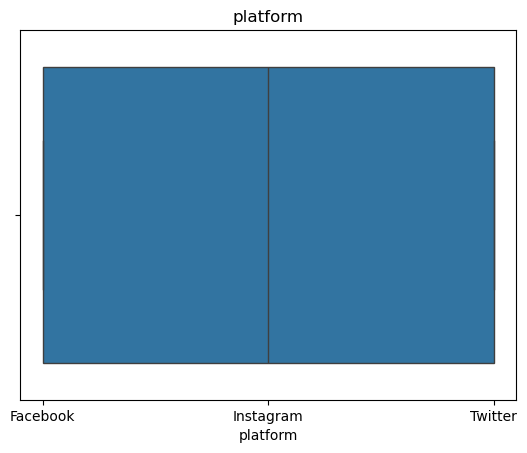

In [8]:
sns.boxplot(d,x='platform')
plt.title("platform")
plt.show()

<Axes: xlabel='post_type'>

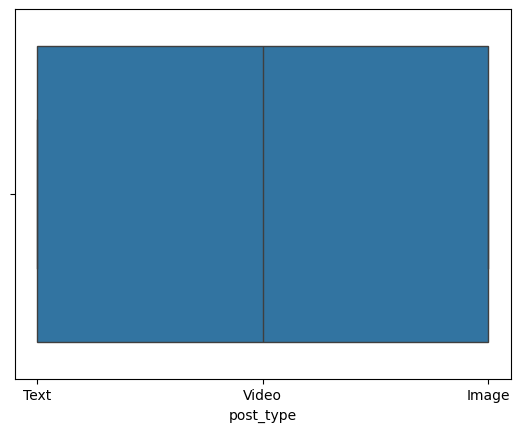

In [10]:
sns.boxplot(d,x='post_type')

<Axes: xlabel='post_length'>

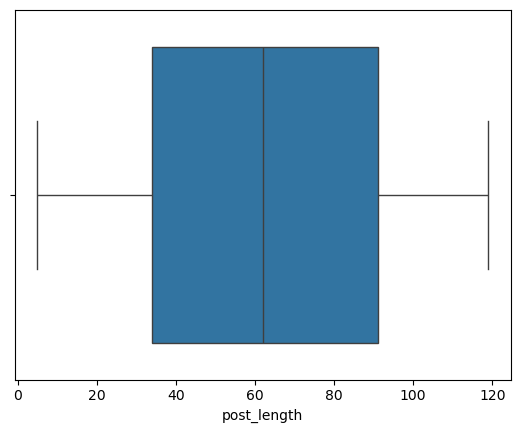

In [9]:
sns.boxplot(d,x='post_length')

<Axes: xlabel='views'>

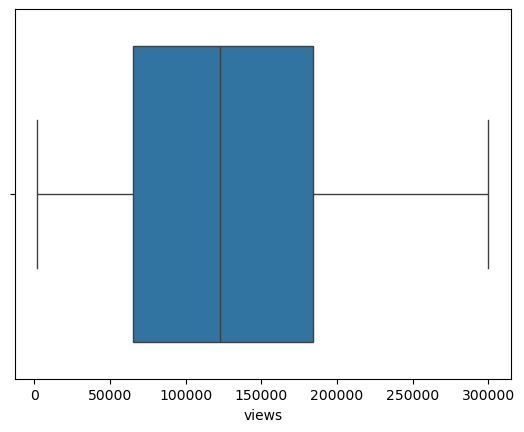

In [11]:
sns.boxplot(d,x='views')

<Axes: xlabel='likes'>

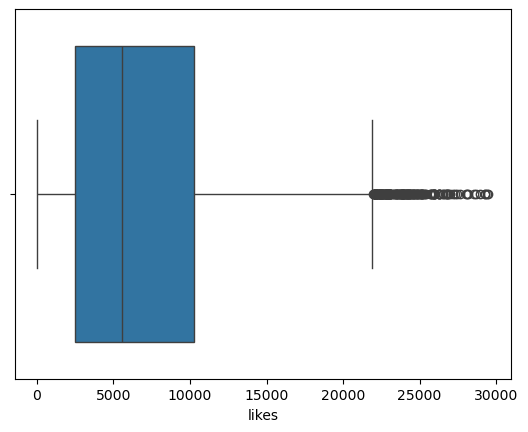

In [12]:
sns.boxplot(d,x='likes')

<Axes: xlabel='comments'>

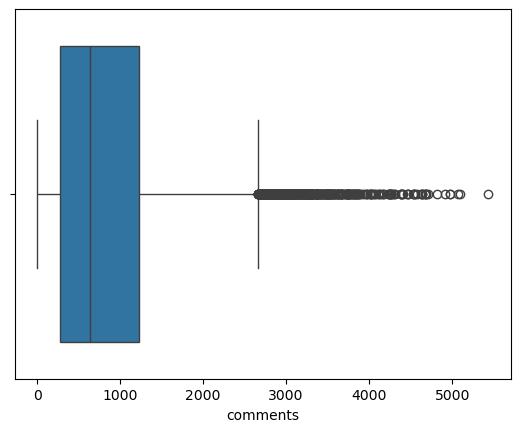

In [13]:
sns.boxplot(d,x='comments')

<Axes: xlabel='shares'>

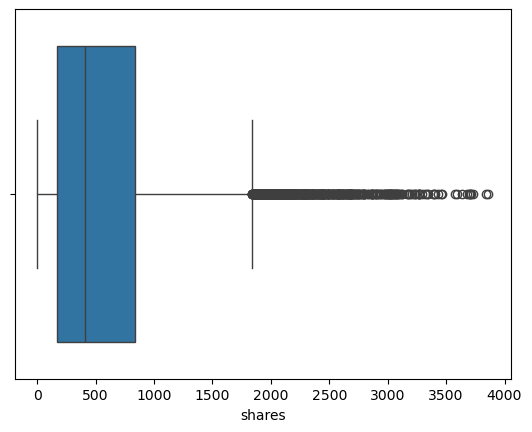

In [14]:
sns.boxplot(d,x='shares')

<Axes: xlabel='engagement_rate'>

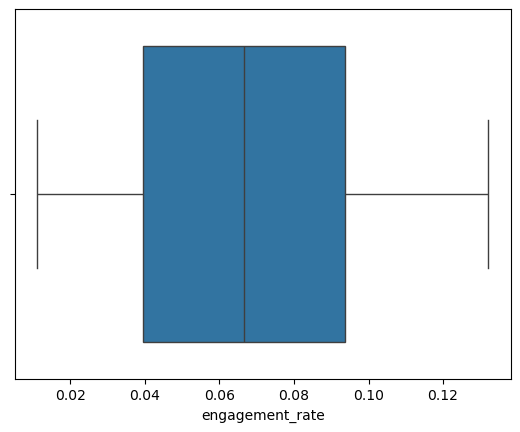

In [16]:
sns.boxplot(d,x='engagement_rate')

#### Observations:
1. likes,share,comments have more outliers

#### Problem statement:
1. Create a Machine learning model to predict Social Media Engagement rate.
2. Based on above problem statement, engagement_rate is target variable
3. engagement_rate is a real numerical data column, Hence, it is regression task.

In [17]:
y = d['engagement_rate']
X = d.drop(columns = 'engagement_rate')

In [18]:
print(y.shape)
print(X.shape)

(10000,)
(10000, 7)


#### Observation:
1. Out of 8 columns is selected as target variable.
2. There are total columns left in the input data
3. Out of input columns, First two columns are categorical and remaining columns are real numerical.

In [20]:
d['platform'].unique()

array(['Facebook', 'Instagram', 'Twitter'], dtype=object)

### Categorical Data Preprocessing:
1. One Hot Encoding

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 7)
(2000, 7)
(8000,)
(2000,)


In [24]:
# let extract only categorical data columns to apply data preprocessing
X_train_cat = X_train[['platform','post_type']]
X_test_cat = X_test[['platform','post_type']]
print(X_train_cat.shape)
print(X_test_cat.shape)

(8000, 2)
(2000, 2)


#### Observations:
1. We have to apply encoding methods on X_train_cat and X_test_cat

#### One Hot Encoding:

In [25]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

X_train_cat_trans = ohe.fit_transform(X_train_cat)
X_test_cat_trans = ohe.transform(X_test_cat)

print(type(X_train_cat_trans))
print(type(X_test_cat_trans))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [27]:
# to convert compress matrix into the dataframe
X_train_cat_trans = pd.DataFrame(X_train_cat_trans.toarray())
X_train_cat_trans.head()

,0,1,2,3,4,5
0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0


In [28]:
X_test_cat_trans = pd.DataFrame(X_test_cat_trans.toarray())
X_test_cat_trans.head()

,0,1,2,3,4,5
0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# to verify

#### Label Encoder (ordinal):

In [30]:
from sklearn.preprocessing import OrdinalEncoder
# here inside function we are not mentioning the order so by default it takes alphabetical order
le = OrdinalEncoder()

X_train_cat_le = le.fit_transform(X_train_cat)
X_test_cat_le = le.transform(X_test_cat)

print(type(X_train_cat_le))
print(type(X_test_cat_le))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [32]:
X_train_cat_le = pd.DataFrame(X_train_cat_le,columns = X_train_cat.columns)
X_train_cat_le.head()

,platform,post_type
0,2.0,1.0
1,0.0,1.0
2,2.0,1.0
3,2.0,0.0
4,1.0,2.0


In [31]:
X_test_cat_le = pd.DataFrame(X_test_cat_le,columns = X_test_cat.columns)
X_test_cat_le.head()

,platform,post_type
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,2.0,1.0
4,0.0,1.0


#### Ordinal Encoder:


In [33]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories = [['Instagram','Twitter','Facebook'],
                                  ['Video','Image','Text']])

X_train_cat_oe = oe.fit_transform(X_train_cat)
X_test_cat_oe = oe.transform(X_test_cat)

print(type(X_train_cat_oe))
print(type(X_test_cat_oe))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [34]:
X_train_cat_oe = pd.DataFrame(X_train_cat_oe,columns = X_train_cat.columns)
X_train_cat_oe.head()

,platform,post_type
0,1.0,2.0
1,2.0,2.0
2,1.0,2.0
3,1.0,1.0
4,0.0,0.0


In [35]:
X_test_cat_oe = pd.DataFrame(X_test_cat_oe,columns = X_test_cat.columns)
X_test_cat_oe.head()

,platform,post_type
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,1.0,2.0
4,2.0,2.0


#### Implementation of Multiple Data Pre-Processing Methods at a time

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,MinMaxScaler
tf = ColumnTransformer(transformers = [('t1',OrdinalEncoder(),[0,1]),
                                       ('t2',MinMaxScaler(),[2,3,4,5,6])])

X_train_trans = tf.fit_transform(X_train)
X_test_trans = tf.transform(X_test)

print(type(X_train_trans))
print(type(X_test_trans))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [37]:
X_train_trans = pd.DataFrame(X_train_trans,columns = X_train.columns)
X_train_trans.head()

,platform,post_type,post_length,views,likes,comments,shares
0,2.0,1.0,0.052632,0.324816,0.240773,0.264793,0.123348
1,0.0,1.0,0.964912,0.603556,0.525347,0.556123,0.115056
2,2.0,1.0,0.736842,0.061578,0.048182,0.047769,0.034465
3,2.0,0.0,0.657895,0.297980,0.228549,0.149794,0.162477
4,1.0,2.0,0.456140,0.619305,0.221011,0.242972,0.100803


In [38]:
X_test_trans = pd.DataFrame(X_test_trans,columns = X_test.columns)
X_test_trans.head()

,platform,post_type,post_length,views,likes,comments,shares
0,1.0,0.0,0.114035,0.883319,0.521680,0.443287,0.361752
1,1.0,0.0,0.456140,0.637841,0.298020,0.272066,0.335061
2,1.0,0.0,0.728070,0.487869,0.281281,0.093768,0.133713
3,2.0,1.0,0.666667,0.515290,0.462803,0.174366,0.180617
4,0.0,1.0,0.877193,0.372726,0.320295,0.139375,0.243846


In [39]:
print(X_train_trans.shape)
print(X_test_trans.shape)

(8000, 7)
(2000, 7)


In [71]:
d = pd.read_csv('Cards_Data.csv')
d

,Card_ID,Customer_ID,Card_Type,Card_Network,Credit_Limit,Card_Status,Contactless,Card_Mode,Issue_Date,Expiry_Date
0,CARD500001,CUST100001,Gold,RuPay,587317,Active,Yes,Physical,2021-04-24,2026-04-24
1,CARD500002,CUST100002,Silver,Visa,150720,Active,Yes,Virtual,2020-06-30,2025-06-30
2,CARD500003,CUST100003,Gold,RuPay,631005,Active,Yes,Physical,2022-04-04,2027-04-04
3,CARD500004,CUST100004,Silver,Mastercard,285015,Expired,Yes,Virtual,2020-07-21,2025-07-21
4,CARD500005,CUST100005,Gold,Mastercard,348591,Active,Yes,Physical,2024-07-24,2029-07-24
...,...,...,...,...,...,...,...,...,...,...
32452,CARD532453,CUST124997,Platinum,Visa,1161328,Active,Yes,Virtual,2019-02-10,2024-02-10
32453,CARD532454,CUST124997,Gold,RuPay,557911,Active,No,Physical,2020-09-08,2025-09-08
32454,CARD532455,CUST124998,Silver,Mastercard,265380,Active,Yes,Physical,2023-06-16,2028-06-16
32455,CARD532456,CUST124999,Classic,RuPay,144707,Active,Yes,Physical,2018-11-02,2023-11-02


In [67]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32457 entries, 0 to 32456
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Card_ID       32457 non-null  object
 1   Customer_ID   32457 non-null  object
 2   Card_Type     32457 non-null  object
 3   Card_Network  32457 non-null  object
 4   Credit_Limit  32457 non-null  int64 
 5   Card_Status   32457 non-null  object
 6   Contactless   32457 non-null  object
 7   Card_Mode     32457 non-null  object
 8   Issue_Date    32457 non-null  object
 9   Expiry_Date   32457 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.5+ MB


In [74]:
d.drop(columns = ['Card_ID','Customer_ID'],inplace = True)

In [75]:
d.drop(columns = ['Issue_Date','Expiry_Date'],inplace = True)

In [76]:
d.duplicated().sum()

np.int64(69)

In [47]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32457 entries, 0 to 32456
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Card_Type     32457 non-null  object
 1   Card_Network  32457 non-null  object
 2   Credit_Limit  32457 non-null  int64 
 3   Card_Status   32457 non-null  object
 4   Contactless   32457 non-null  object
 5   Card_Mode     32457 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.5+ MB


In [68]:
d.isnull().sum()

Card_ID         0
Customer_ID     0
Card_Type       0
Card_Network    0
Credit_Limit    0
Card_Status     0
Contactless     0
Card_Mode       0
Issue_Date      0
Expiry_Date     0
dtype: int64

In [78]:
d.drop_duplicates(inplace = True)

In [79]:
d.duplicated().sum()

np.int64(0)

AttributeError: module 'seaborn' has no attribute 'subplot'

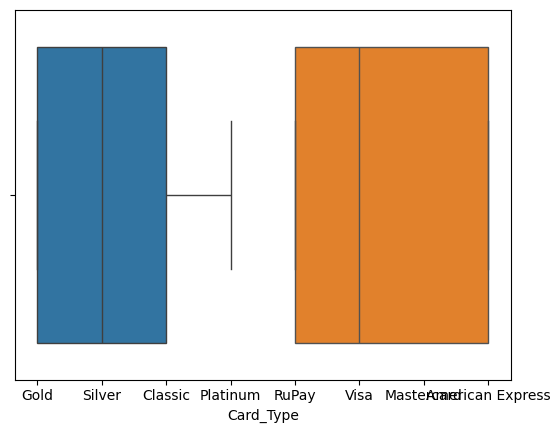

In [48]:
a = sns.boxplot(d,x = 'Card_Type')
b = sns.boxplot(d,x = 'Card_Network')
sns.subplot(1,1,a)

#### Problem Statement:
1. Target variable = card_status
2. classification model

In [80]:
y = d['Card_Status']
X = d.drop(columns = 'Card_Status')
print(X.shape)
print(y.shape)

(32388, 5)
(32388,)


In [61]:
d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32388 entries, 0 to 32456
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Card_Type     32388 non-null  object
 1   Card_Network  32388 non-null  object
 2   Credit_Limit  32388 non-null  int64 
 3   Card_Status   32388 non-null  object
 4   Contactless   32388 non-null  object
 5   Card_Mode     32388 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.7+ MB


In [84]:
d['Card_Mode'].unique()

array(['Physical', 'Virtual'], dtype=object)

In [96]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25910 entries, 5664 to 15008
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Card_Type     25910 non-null  object
 1   Card_Network  25910 non-null  object
 2   Credit_Limit  25910 non-null  int64 
 3   Contactless   25910 non-null  object
 4   Card_Mode     25910 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.2+ MB


In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
tf = ColumnTransformer(transformers = [('t1',OrdinalEncoder(),[0,1,3,4]),
                                       ('t2',MinMaxScaler(),[2])])
X_train_trans = tf.fit_transform(X_train)
X_test_trans = tf.transform(X_test)

print(type(X_train_trans))
print(type(X_test_trans))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
tf = ColumnTransformer(transformers = [('t1',OrdinalEncoder(),["Card_Type", "Card_Network", "Contactless", "Card_Mode"]),
                                       ('t2', MinMaxScaler(), ["Credit_Limit"])])
X_train_trans = tf.fit_transform(X_train)
X_test_trans = tf.transform(X_test)

print(type(X_train_trans))
print(type(X_test_trans))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [101]:
X_train_trans = pd.DataFrame(X_train_trans,columns = X_train.columns)
X_train_trans.head()

,Card_Type,Card_Network,Credit_Limit,Contactless,Card_Mode
0,0.0,0.0,1.0,0.0,0.025808
1,2.0,2.0,1.0,0.0,0.486193
2,3.0,3.0,1.0,0.0,0.171685
3,2.0,2.0,1.0,0.0,0.598010
4,3.0,1.0,1.0,0.0,0.094814


In [102]:
X_test_trans = pd.DataFrame(X_test_trans,columns = X_test.columns)
X_test_trans.head()

,Card_Type,Card_Network,Credit_Limit,Contactless,Card_Mode
0,2.0,2.0,1.0,1.0,0.733497
1,2.0,2.0,1.0,1.0,0.732220
2,0.0,3.0,1.0,0.0,0.068625
3,2.0,1.0,0.0,0.0,0.489680
4,2.0,3.0,1.0,1.0,0.499444
